# 🏡 Property Sales — Time Series Analysis

Este notebook realiza uma análise completa de séries temporais sobre o dataset de vendas de imóveis do Kaggle (`htagholdings/property-sales`).

### Fluxo do notebook:
1. **Carregamento & Exploração** dos dados
2. **Limpeza & Preparação** da série temporal
3. **Análise Exploratória** (EDA temporal)
4. **Decomposição** (tendência, sazonalidade, resíduo)
5. **Teste de Estacionariedade** (ADF)
6. **Modelagem** com SARIMA
7. **Forecast** e avaliação de métricas


In [1]:
# ── Instalação de dependências ──────────────────────────────────────────────
!pip install kagglehub[pandas-datasets] statsmodels pmdarima --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 23.0 MB/s eta 0:00:00


In [2]:
# ── Imports ─────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Estilo visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
FIGSIZE = (14, 5)

print('✅ Imports concluídos!')

✅ Imports concluídos!


---
## 1. Carregamento dos Dados

In [3]:
# Listar arquivos disponíveis no dataset
import kagglehub, os
path = kagglehub.dataset_download('htagholdings/property-sales')
print('Arquivos disponíveis:')
for f in os.listdir(path):
    print(' ', f)

# Carregar o arquivo correto
file_path = 'raw_sales.csv'  # arquivo principal do dataset
df_raw = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    'htagholdings/property-sales',
    file_path
)

print(f'Shape: {df_raw.shape}')
print(f'Colunas: {df_raw.columns.tolist()}')
df_raw.head()

Arquivos disponíveis:
  raw_sales.csv
  ma_lga_12345.csv
Shape: (29580, 5)
Colunas: ['datesold', 'postcode', 'price', 'propertyType', 'bedrooms']


,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [4]:
print('\n📊 Tipos de dados:')
print(df_raw.dtypes)
print('\n🔍 Valores nulos:')
print(df_raw.isnull().sum())
print('\n📈 Estatísticas descritivas:')
df_raw.describe()


📊 Tipos de dados:
datesold        object
postcode         int64
price            int64
propertyType    object
bedrooms         int64
dtype: object

🔍 Valores nulos:
datesold        0
postcode        0
price           0
propertyType    0
bedrooms        0
dtype: int64

📈 Estatísticas descritivas:


,postcode,price,bedrooms
count,29580.000000,2.958000e+04,29580.000000
mean,2730.249730,6.097363e+05,3.250169
std,146.717292,2.817079e+05,0.951275
min,2600.000000,5.650000e+04,0.000000
25%,2607.000000,4.400000e+05,3.000000
50%,2615.000000,5.500000e+05,3.000000
75%,2905.000000,7.050000e+05,4.000000
max,2914.000000,8.000000e+06,5.000000


---
## 2. Limpeza & Preparação da Série Temporal

In [5]:
df = df_raw.copy()

# ── Identificar coluna de data ───────────────────────────────────────────────
# O dataset tem colunas como 'datesold', 'price', 'bedrooms', 'postcode', 'propertyType'
date_col = 'datesold'
price_col = 'price'

df[date_col] = pd.to_datetime(df[date_col])
df = df.dropna(subset=[date_col, price_col])
df = df[df[price_col] > 0]  # Remove preços inválidos

print(f'Período: {df[date_col].min().date()} → {df[date_col].max().date()}')
print(f'Total de registros: {len(df):,}')

Período: 2007-02-07 → 2019-07-27
Total de registros: 29,580


In [6]:
# ── Agregar por mês: mediana de preço e volume de vendas ────────────────────
df.set_index(date_col, inplace=True)

monthly = df[price_col].resample('MS').agg(
    median_price='median',
    volume='count'
)

# Preencher meses sem vendas
monthly = monthly.asfreq('MS').interpolate(method='time')

print(f'Série mensal: {len(monthly)} períodos')
monthly.head(10)

Série mensal: 150 períodos


,median_price,volume
datesold,,
2007-02-01,407500.0,2
2007-03-01,328000.0,3
2007-04-01,465000.0,3
2007-05-01,339500.0,2
2007-06-01,451000.0,6
2007-07-01,525000.0,19
2007-08-01,520000.0,23
2007-09-01,503000.0,20
2007-10-01,465000.0,20


---
## 3. Análise Exploratória Temporal (EDA)

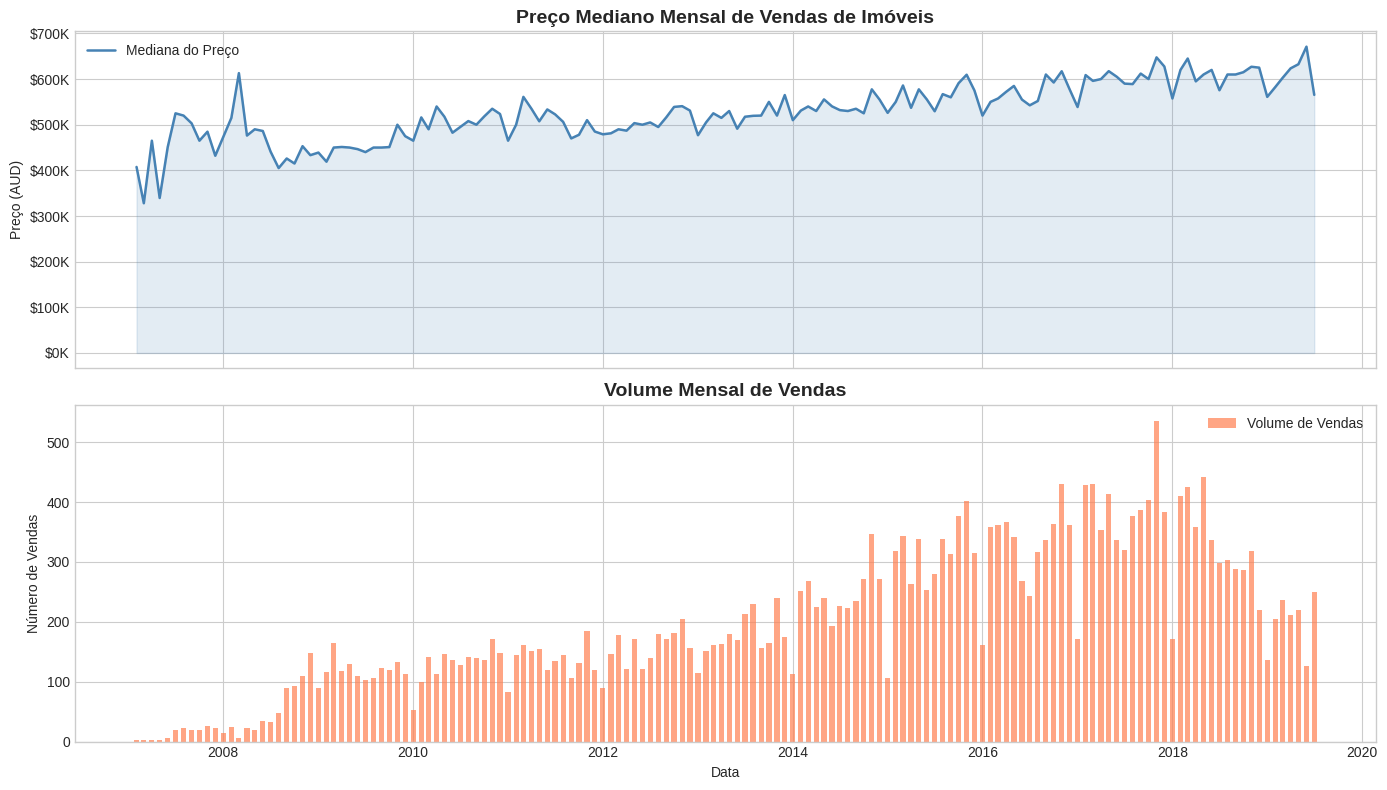

📊 Visão geral da série plotada.


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Preço mediano
axes[0].plot(monthly.index, monthly['median_price'], color='steelblue', linewidth=1.8, label='Mediana do Preço')
axes[0].fill_between(monthly.index, monthly['median_price'], alpha=0.15, color='steelblue')
axes[0].set_title('Preço Mediano Mensal de Vendas de Imóveis', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Preço (AUD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
axes[0].legend()

# Volume de vendas
axes[1].bar(monthly.index, monthly['volume'], color='coral', alpha=0.7, width=20, label='Volume de Vendas')
axes[1].set_title('Volume Mensal de Vendas', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Número de Vendas')
axes[1].set_xlabel('Data')
axes[1].legend()

plt.tight_layout()
plt.savefig('01_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Visão geral da série plotada.')

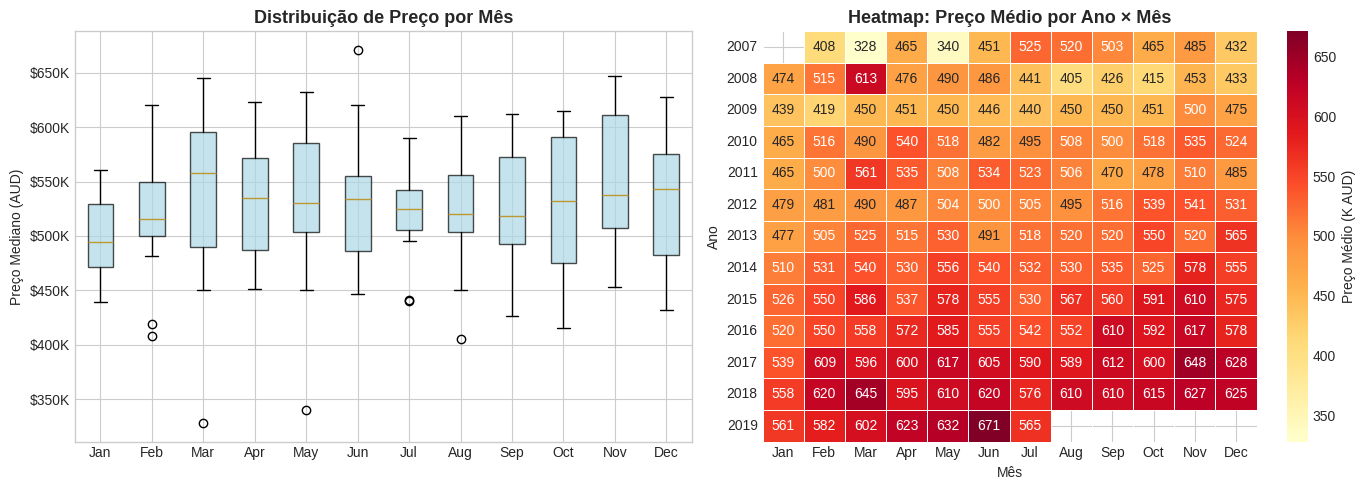

In [8]:
# ── Padrão sazonal por mês do ano ───────────────────────────────────────────
monthly_copy = monthly.copy()
monthly_copy['month'] = monthly_copy.index.month
monthly_copy['year'] = monthly_copy.index.year
monthly_copy['month_name'] = monthly_copy.index.strftime('%b')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box por mês
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal_df = monthly_copy.groupby('month_name')['median_price'].apply(list).reindex(month_order)

axes[0].boxplot([v for v in seasonal_df], labels=month_order, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[0].set_title('Distribuição de Preço por Mês', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Preço Mediano (AUD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# Heatmap ano x mês
pivot = monthly_copy.pivot_table(values='median_price', index='year', columns='month', aggfunc='mean')
pivot.columns = month_order[:len(pivot.columns)]
sns.heatmap(pivot/1e3, ax=axes[1], cmap='YlOrRd', fmt='.0f', annot=True,
            linewidths=0.5, cbar_kws={'label': 'Preço Médio (K AUD)'})
axes[1].set_title('Heatmap: Preço Médio por Ano × Mês', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Ano')

plt.tight_layout()
plt.savefig('02_seasonal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Decomposição da Série Temporal

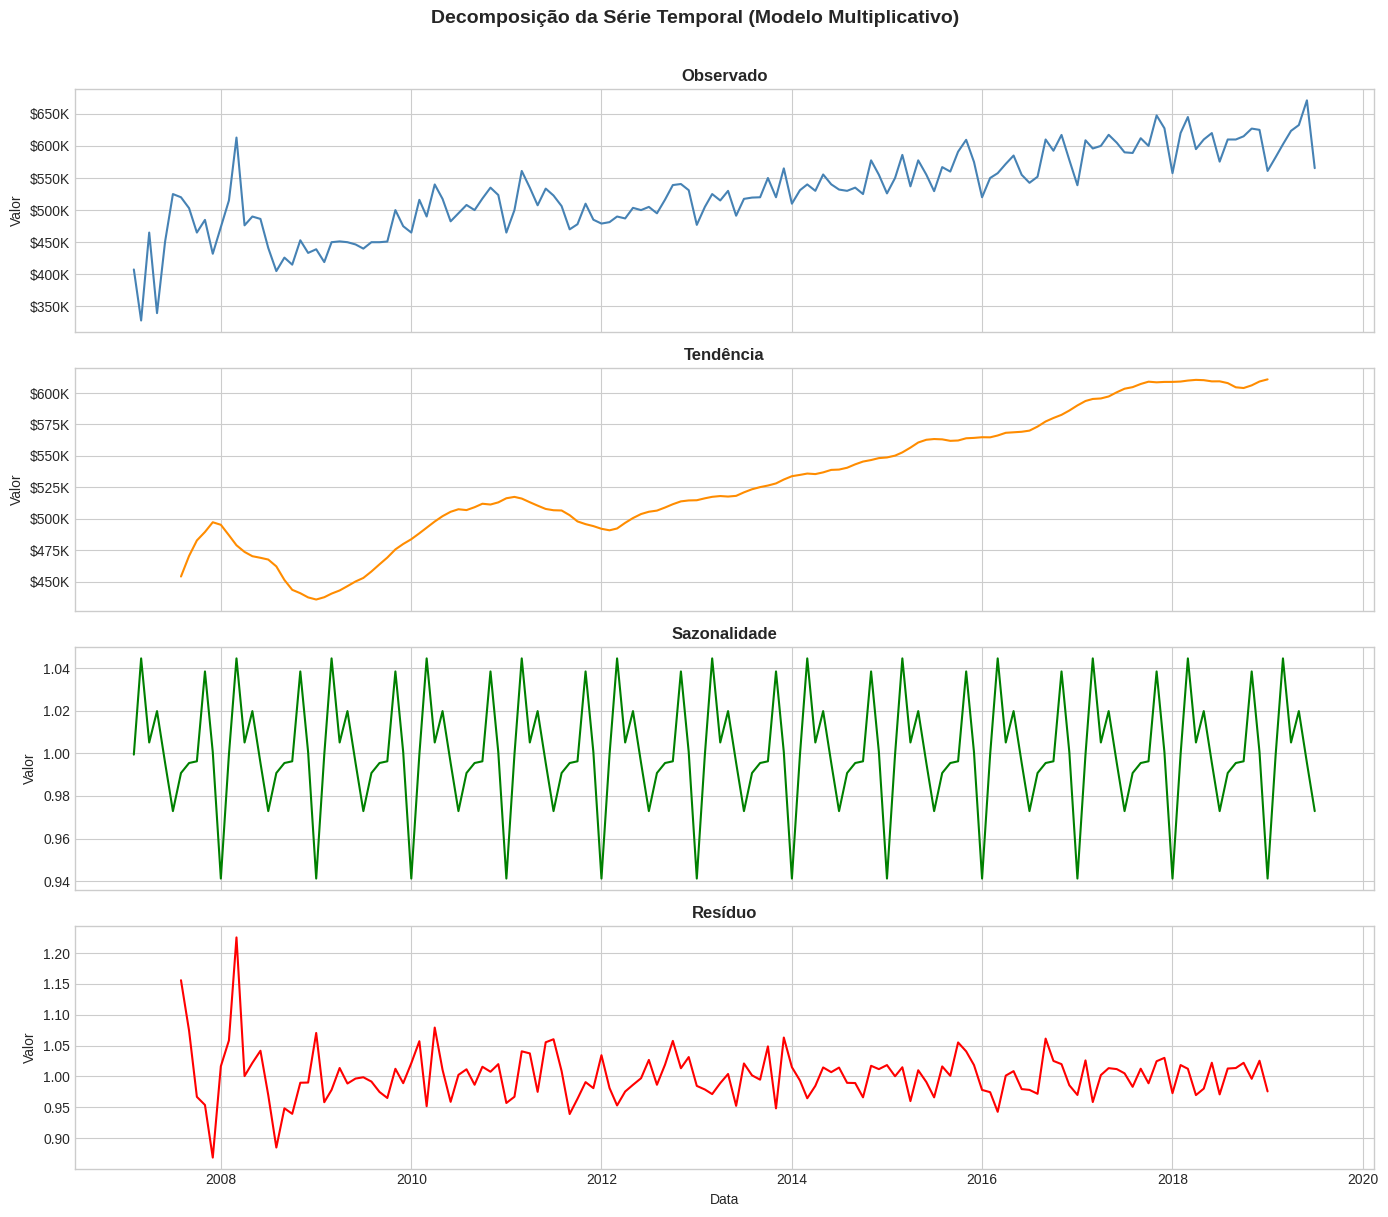

In [9]:
ts = monthly['median_price'].dropna()

# Decomposição multiplicativa (mais adequada para séries com tendência crescente)
decomp = seasonal_decompose(ts, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
components = {
    'Observado': decomp.observed,
    'Tendência': decomp.trend,
    'Sazonalidade': decomp.seasonal,
    'Resíduo': decomp.resid
}
colors = ['steelblue', 'darkorange', 'green', 'red']

for ax, (title, data), color in zip(axes, components.items(), colors):
    ax.plot(data, color=color, linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor')
    if title in ['Observado', 'Tendência']:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

axes[-1].set_xlabel('Data')
fig.suptitle('Decomposição da Série Temporal (Modelo Multiplicativo)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Teste de Estacionariedade (ADF) e ACF/PACF

In [10]:
def adf_test(series, title=''):
    result = adfuller(series.dropna())
    print(f'\n📌 ADF Test — {title}')
    print(f'   Estatística ADF : {result[0]:.4f}')
    print(f'   p-value         : {result[1]:.4f}')
    print(f'   Lags utilizados : {result[2]}')
    for key, val in result[4].items():
        print(f'   Valor crítico ({key}): {val:.4f}')
    if result[1] < 0.05:
        print('   ✅ Série ESTACIONÁRIA (rejeita H0)')
    else:
        print('   ⚠️  Série NÃO ESTACIONÁRIA (falha em rejeitar H0)')
    return result[1]

p1 = adf_test(ts, 'Preço Mediano (original)')

# Primeira diferença
ts_diff = ts.diff().dropna()
p2 = adf_test(ts_diff, 'Preço Mediano (1ª diferença)')

# Diferença sazonal
ts_sdiff = ts.diff(12).dropna()
p3 = adf_test(ts_sdiff, 'Preço Mediano (diferença sazonal 12)')


📌 ADF Test — Preço Mediano (original)
   Estatística ADF : -1.2422
   p-value         : 0.6552
   Lags utilizados : 5
   Valor crítico (1%): -3.4766
   Valor crítico (5%): -2.8818
   Valor crítico (10%): -2.5776
   ⚠️  Série NÃO ESTACIONÁRIA (falha em rejeitar H0)

📌 ADF Test — Preço Mediano (1ª diferença)
   Estatística ADF : -9.8420
   p-value         : 0.0000
   Lags utilizados : 4
   Valor crítico (1%): -3.4766
   Valor crítico (5%): -2.8818
   Valor crítico (10%): -2.5776
   ✅ Série ESTACIONÁRIA (rejeita H0)

📌 ADF Test — Preço Mediano (diferença sazonal 12)
   Estatística ADF : -7.4477
   p-value         : 0.0000
   Lags utilizados : 11
   Valor crítico (1%): -3.4833
   Valor crítico (5%): -2.8848
   Valor crítico (10%): -2.5792
   ✅ Série ESTACIONÁRIA (rejeita H0)


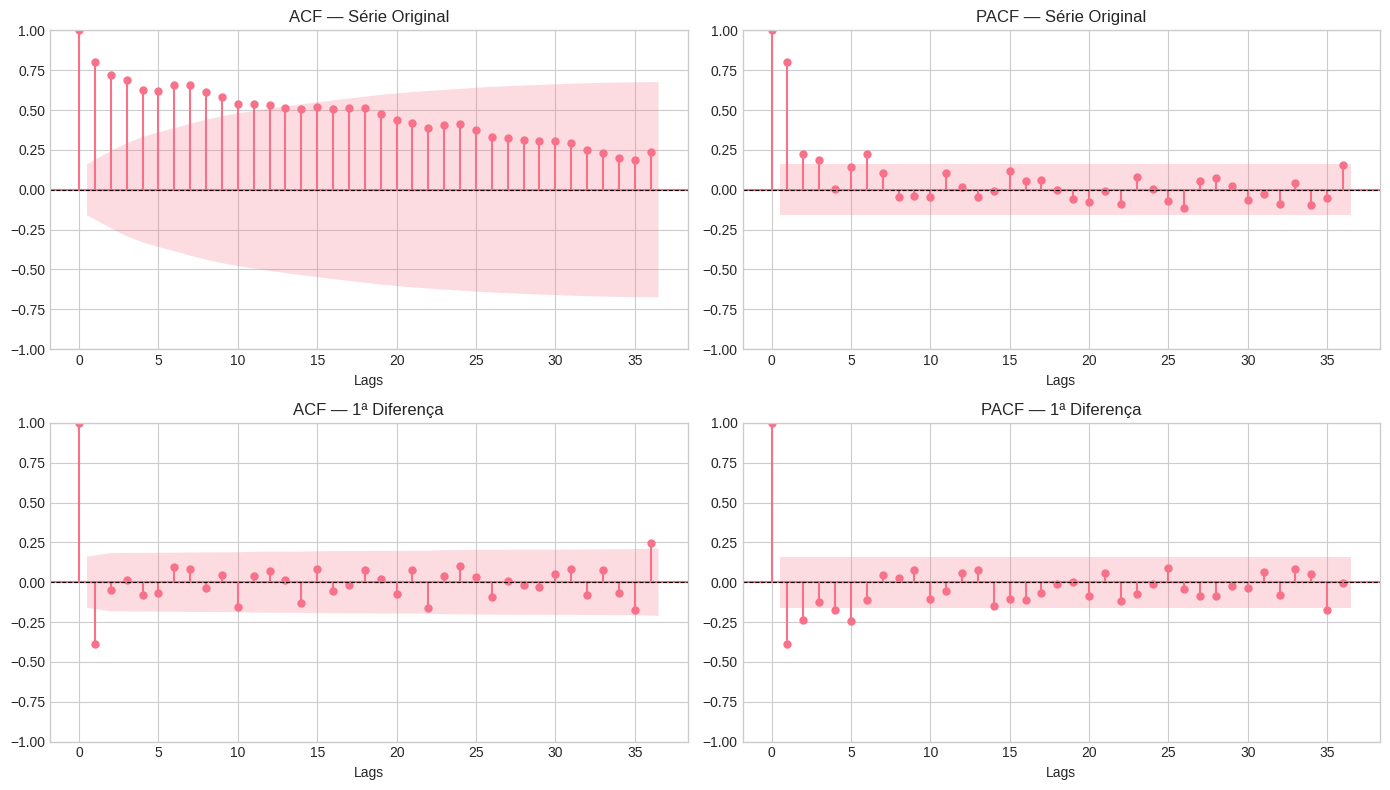

In [11]:
# ── ACF e PACF para identificar parâmetros ARIMA ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(ts, lags=36, ax=axes[0, 0], title='ACF — Série Original')
plot_pacf(ts, lags=36, ax=axes[0, 1], title='PACF — Série Original', method='ywm')
plot_acf(ts_diff, lags=36, ax=axes[1, 0], title='ACF — 1ª Diferença')
plot_pacf(ts_diff, lags=36, ax=axes[1, 1], title='PACF — 1ª Diferença', method='ywm')

for ax in axes.flat:
    ax.axhline(y=0, linestyle='--', color='black', linewidth=0.8)
    ax.set_xlabel('Lags')

plt.tight_layout()
plt.savefig('04_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Modelagem — SARIMA

> O modelo **SARIMA(p,d,q)(P,D,Q)[m]** captura tendência, autocorrelação e sazonalidade.

In [12]:
# ── Divisão treino/teste (últimos 12 meses para teste) ──────────────────────
TEST_PERIODS = 12
train = ts.iloc[:-TEST_PERIODS]
test  = ts.iloc[-TEST_PERIODS:]

print(f'Treino: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} obs)')
print(f'Teste : {test.index[0].date()} → {test.index[-1].date()} ({len(test)} obs)')

Treino: 2007-02-01 → 2018-07-01 (138 obs)
Teste : 2018-08-01 → 2019-07-01 (12 obs)


In [13]:
# ── Seleção automática do melhor modelo via AIC ─────────────────────────────
# Usamos pmdarima para auto_arima quando disponível, senão testamos manualmente
try:
    import pmdarima as pm
    print('🔍 Rodando auto_arima (pode levar alguns minutos)...')
    auto_model = pm.auto_arima(
        train,
        start_p=0, start_q=0, max_p=3, max_q=3,
        d=1, D=1, m=12,
        seasonal=True,
        stepwise=True,
        information_criterion='aic',
        trace=True,
        error_action='ignore',
        suppress_warnings=True
    )
    order = auto_model.order
    seasonal_order = auto_model.seasonal_order
    print(f'\n✅ Melhor modelo: SARIMA{order}{seasonal_order}')

except ImportError:
    print('pmdarima não disponível — usando SARIMA(1,1,1)(1,1,0,12) padrão')
    order = (1, 1, 1)
    seasonal_order = (1, 1, 0, 12)

🔍 Rodando auto_arima (pode levar alguns minutos)...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=0.81 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=3057.598, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=2996.567, Time=0.16 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=2980.136, Time=0.20 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=3036.922, Time=0.06 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=2980.401, Time=0.34 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=2978.686, Time=0.77 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=2977.313, Time=1.01 sec
 ARIMA(0,1,1)(2,1,2)[12]             : AIC=2975.173, Time=1.53 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=2973.290, Time=0.74 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=2973.940, Time=0.37 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=3006.941, Time=0.14 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=3049.925, Time=0.54 sec
 ARIMA(1,1,1)(2,1,1)[12]             : 

In [14]:
# ── Ajuste do modelo SARIMA ─────────────────────────────────────────────────
model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       median_price   No. Observations:                  138
Model:             SARIMAX(1, 1, 1)x(2, 1, 1, 12)   Log Likelihood               -1155.805
Date:                            Thu, 19 Feb 2026   AIC                           2323.610
Time:                                    23:11:08   BIC                           2339.241
Sample:                                02-01-2007   HQIC                          2329.936
                                     - 07-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0079      0.415      0.019      0.985      -0.806       0.822
ma.L1         -0.7165      0.305   

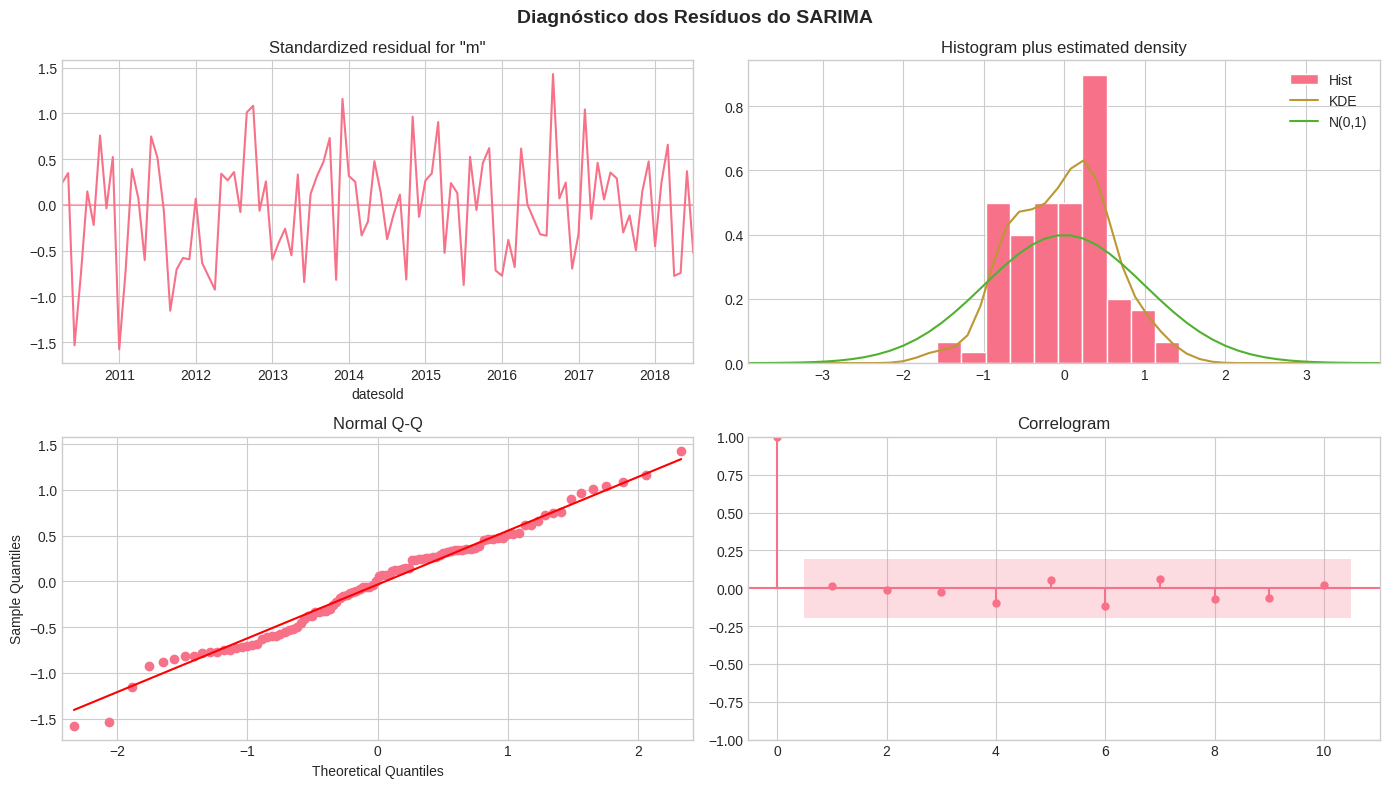

In [15]:
# ── Diagnóstico dos resíduos ────────────────────────────────────────────────
fig = results.plot_diagnostics(figsize=(14, 8))
fig.suptitle('Diagnóstico dos Resíduos do SARIMA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_residuals_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Forecast & Avaliação

In [16]:
# ── Previsão no período de teste ────────────────────────────────────────────
forecast_test = results.get_forecast(steps=TEST_PERIODS)
pred_mean = forecast_test.predicted_mean
conf_int  = forecast_test.conf_int(alpha=0.05)

# ── Métricas ────────────────────────────────────────────────────────────────
mae   = mean_absolute_error(test, pred_mean)
rmse  = np.sqrt(mean_squared_error(test, pred_mean))
mape  = np.mean(np.abs((test.values - pred_mean.values) / test.values)) * 100

print(f'\n📏 Métricas de Avaliação (período de teste — {TEST_PERIODS} meses):')
print(f'   MAE  : ${mae:,.0f}')
print(f'   RMSE : ${rmse:,.0f}')
print(f'   MAPE : {mape:.2f}%')


📏 Métricas de Avaliação (período de teste — 12 meses):
   MAE  : $21,180
   RMSE : $26,453
   MAPE : 3.50%


In [17]:
# ── Previsão futura (próximos 12 meses além dos dados) ──────────────────────
FUTURE_PERIODS = 12
model_full = SARIMAX(
    ts,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast_future = model_full.get_forecast(steps=FUTURE_PERIODS)
future_mean = forecast_future.predicted_mean
future_ci   = forecast_future.conf_int(alpha=0.05)

print(f'\n🔮 Previsão para os próximos {FUTURE_PERIODS} meses:')
print(pd.DataFrame({
    'Previsto': future_mean.values,
    'IC Inferior (95%)': future_ci.iloc[:, 0].values,
    'IC Superior (95%)': future_ci.iloc[:, 1].values
}, index=future_mean.index).applymap(lambda x: f'${x:,.0f}'))


🔮 Previsão para os próximos 12 meses:
            Previsto IC Inferior (95%) IC Superior (95%)
2019-08-01  $609,714          $541,456          $677,972
2019-09-01  $633,501          $562,828          $704,174
2019-10-01  $626,087          $552,914          $699,260
2019-11-01  $654,290          $578,701          $729,879
2019-12-01  $635,849          $557,920          $713,779
2020-01-01  $576,401          $496,199          $656,603
2020-02-01  $625,876          $543,463          $708,288
2020-03-01  $638,804          $554,240          $723,368
2020-04-01  $629,593          $542,930          $716,256
2020-05-01  $643,014          $554,302          $731,726
2020-06-01  $657,744          $567,030          $748,459
2020-07-01  $598,378          $505,704          $691,053


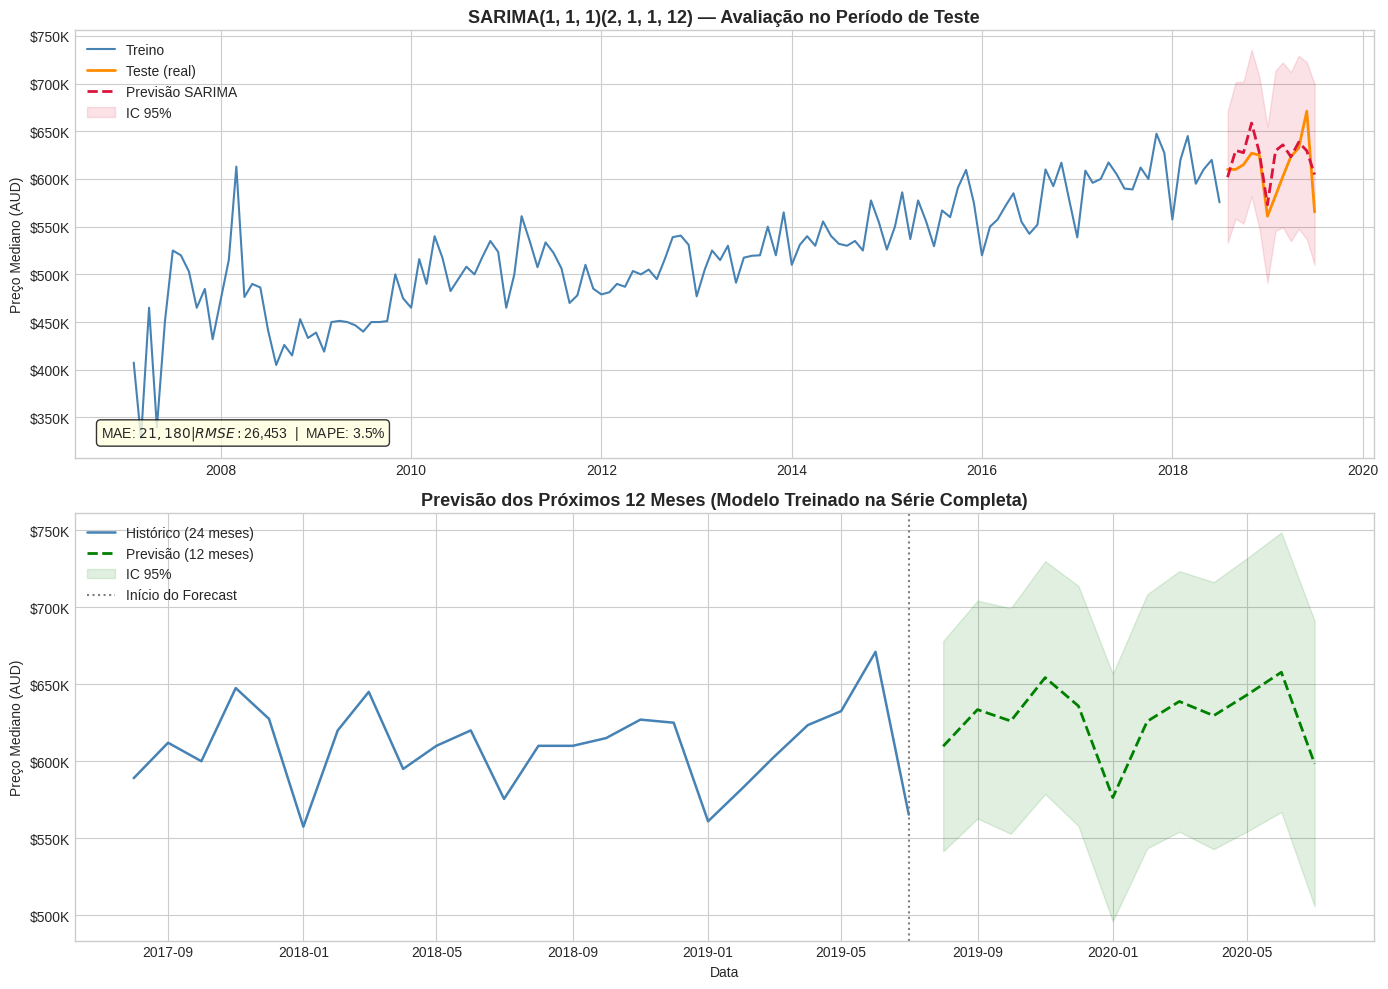

✅ Análise de séries temporais concluída!


In [18]:
# ── Plot final: histórico + teste + forecast ─────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Painel 1: Fit no período de teste ---
ax1 = axes[0]
ax1.plot(train.index, train, color='steelblue', label='Treino', linewidth=1.5)
ax1.plot(test.index, test, color='darkorange', label='Teste (real)', linewidth=2)
ax1.plot(pred_mean.index, pred_mean, color='crimson', linestyle='--', label='Previsão SARIMA', linewidth=2)
ax1.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 color='crimson', alpha=0.12, label='IC 95%')
ax1.set_title(f'SARIMA{order}{seasonal_order} — Avaliação no Período de Teste', fontsize=13, fontweight='bold')
ax1.set_ylabel('Preço Mediano (AUD)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax1.legend(loc='upper left')
ax1.text(0.02, 0.05,
         f'MAE: ${mae:,.0f}  |  RMSE: ${rmse:,.0f}  |  MAPE: {mape:.1f}%',
         transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Painel 2: Forecast futuro ---
ax2 = axes[1]
# Últimos 24 meses da série histórica para contexto
hist_window = ts.iloc[-24:]
ax2.plot(hist_window.index, hist_window, color='steelblue', label='Histórico (24 meses)', linewidth=1.8)
ax2.plot(future_mean.index, future_mean, color='green', linestyle='--', label='Previsão (12 meses)', linewidth=2)
ax2.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                 color='green', alpha=0.12, label='IC 95%')
ax2.axvline(ts.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Início do Forecast')
ax2.set_title(f'Previsão dos Próximos {FUTURE_PERIODS} Meses (Modelo Treinado na Série Completa)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Preço Mediano (AUD)')
ax2.set_xlabel('Data')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig('06_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Análise de séries temporais concluída!')

---
## 8. Resumo dos Resultados


In [19]:
summary = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'MAPE', 'Modelo', 'Período de Treino', 'Período de Teste'],
    'Valor': [
        f'${mae:,.0f}',
        f'${rmse:,.0f}',
        f'{mape:.2f}%',
        f'SARIMA{order}{seasonal_order}',
        f'{train.index[0].date()} → {train.index[-1].date()}',
        f'{test.index[0].date()} → {test.index[-1].date()}'
    ]
})

print('\n📋 RESUMO DO MODELO')
print('=' * 50)
for _, row in summary.iterrows():
    print(f'  {row["Métrica"]:<25}: {row["Valor"]}')
print('=' * 50)

print('\n🔮 Previsão Futura:')
for date, val in future_mean.items():
    ci_lo = future_ci.iloc[list(future_mean.index).index(date), 0]
    ci_hi = future_ci.iloc[list(future_mean.index).index(date), 1]
    print(f'  {date.strftime("%Y-%m")}: ${val:,.0f}  (IC: ${ci_lo:,.0f} – ${ci_hi:,.0f})')


📋 RESUMO DO MODELO
  MAE                      : $21,180
  RMSE                     : $26,453
  MAPE                     : 3.50%
  Modelo                   : SARIMA(1, 1, 1)(2, 1, 1, 12)
  Período de Treino        : 2007-02-01 → 2018-07-01
  Período de Teste         : 2018-08-01 → 2019-07-01

🔮 Previsão Futura:
  2019-08: $609,714  (IC: $541,456 – $677,972)
  2019-09: $633,501  (IC: $562,828 – $704,174)
  2019-10: $626,087  (IC: $552,914 – $699,260)
  2019-11: $654,290  (IC: $578,701 – $729,879)
  2019-12: $635,849  (IC: $557,920 – $713,779)
  2020-01: $576,401  (IC: $496,199 – $656,603)
  2020-02: $625,876  (IC: $543,463 – $708,288)
  2020-03: $638,804  (IC: $554,240 – $723,368)
  2020-04: $629,593  (IC: $542,930 – $716,256)
  2020-05: $643,014  (IC: $554,302 – $731,726)
  2020-06: $657,744  (IC: $567,030 – $748,459)
  2020-07: $598,378  (IC: $505,704 – $691,053)
